# **Project: Nghiên cứu mô hình học đa phương thức dựa trên đồ thị, chuẩn đoán bệnh nghề nghiệp dựa trên ảnh X-quang và dữ liệu lâm sàng**
## **Nhánh Timeseries: Xử lý dữ liệu lâm sàng & Train Base Model (Đã tối ưu & chống rò rỉ dữ liệu)**

# Table of Contents
* [1. Load Data Linh Hoạt (Local / Google Sheet)](#loading-data)
* [0.1 Định danh bệnh nhân (patient_group)](#patient-group)
* [2. Fill Missing & Outliers](#fill-missing)
* [3. Feature Engineering & Encoding](#encoding)
* [4. Phân Loại Nghề 10 Cấp Độ](#job-classification)
* [5. Tách Nhánh Dữ Liệu & Split Train/Val/Test](#data-splitting)
* [0.2 Kiểm chứng hash & đo rò rỉ bệnh nhân](#leakage-audit)
* [6. Kiến Trúc Mô Hình Keras Multi-Input](#model-architecture)
* [7. Huấn Luyện & Đánh Giá trên Tập Test Hold-out](#model-training)
* [8. Trích Xuất Vector Đặc Trưng Lâm Sàng cho Fusion](#feature-extraction)

In [1]:
# === Optional: Mount Google Drive if running on Google Colab ===
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("✅ Mounted Google Drive successfully.")
except ImportError:
    print("ℹ️ Running in Local environment (Google Colab module not found). Skipping drive mount.")
except Exception as e:
    print(f"ℹ️ Could not mount Google Drive: {e}. Proceeding with local configuration.")

# --- Thiết lập tính lập lại (Reproducibility Seed) ---
import os
import random
import numpy as np
import tensorflow as tf

def set_reproducibility(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception as e:
        pass
    print(f"✅ Reproducibility seeds set to {seed}")

set_reproducibility(42)


ℹ️ Running in Local environment (Google Colab module not found). Skipping drive mount.


I0000 00:00:1785994863.695916 2111022 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785994864.279347 2111022 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785994866.690156 2111022 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


✅ Reproducibility seeds set to 42


In [2]:
# === 1) Load Data Linh Hoạt (Ưu tiên File Local -> Fallback Google Sheet) & Lọc Cột ===

import os
import re
from io import BytesIO
import pandas as pd
import requests

LOCAL_DATA_PATH = "data/Main_data_Merged_1835_Images.xlsx"
RAW_SHEET_URL = "https://docs.google.com/spreadsheets/d/1MBTFK4dw-PBbh8NA2HEaNo0_CVemTJfF/edit?usp=drive_link&ouid=103230800443557501737&rtpof=true&sd=true"

df_raw = None

# 1) Kiểm tra nạp từ Local File trước
if os.path.exists(LOCAL_DATA_PATH):
    print(f"✅ Tìm thấy dữ liệu Local: {LOCAL_DATA_PATH}. Đang nạp dữ liệu...")
    df_raw = pd.read_excel(LOCAL_DATA_PATH)
    print(f"✅ Loaded local data successfully. Shape: {df_raw.shape}")
else:
    print(f"⚠️ Không tìm thấy file local tại '{LOCAL_DATA_PATH}'. Đang tải từ Google Sheet URL...")
    m = re.search(r"/spreadsheets/d/([^/]+)/", RAW_SHEET_URL)
    if not m:
        raise ValueError("Không trích xuất được spreadsheet id từ RAW_SHEET_URL.")
    
    raw_sid = m.group(1)
    raw_export_url = f"https://docs.google.com/spreadsheets/d/{raw_sid}/export?format=xlsx"
    
    resp = requests.get(raw_export_url)
    if resp.status_code != 200 or (resp.headers.get("content-type", "").find("spreadsheet") == -1 and resp.content[:4] != b"PK\x03\x04"):
        raise RuntimeError(f"Không tải được .xlsx từ Google Sheet. status_code={resp.status_code}")
    
    df_raw = pd.read_excel(BytesIO(resp.content))
    print(f"✅ Loaded online raw data successfully. Shape: {df_raw.shape}")

# --- Lọc cột định danh & Cột rò rỉ X-quang ---
explicit_drop = {
    "id", "tinh", "hoten", "sdt", "sobh", "bnncuthe", "nam",
    # Cột kết quả/phân tích phim X-quang (tránh rò rỉ sang nhánh ảnh)
    "chatluongphim", "ketqua", "matdotonthuong", "tonthuongkhac", "kichthuoctt",
}

pattern_drop = []
for col in df_raw.columns:
    c = str(col).strip()
    if re.match(r"^[BCDE]\s*\d+", c, flags=re.IGNORECASE):
        pattern_drop.append(col)
        continue
    m_f = re.match(r"^F\s*(\d+)", c, flags=re.IGNORECASE)
    if m_f:
        f_num = int(m_f.group(1))
        if 1 <= f_num <= 3 or 6 <= f_num <= 13:
            pattern_drop.append(col)
            continue

cols_to_drop = []
for c in df_raw.columns:
    if str(c).strip().lower() in explicit_drop:
        cols_to_drop.append(c)
cols_to_drop.extend(pattern_drop)

seen = set()
cols_to_drop = [c for c in cols_to_drop if not (c in seen or seen.add(c))]

before_cols = df_raw.shape[1]
df_pruned = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns], errors="ignore")
after_cols = df_pruned.shape[1]

print("\n✅ Pruned columns (loại bỏ thông tin cá nhân & dữ liệu X-quang):")
print(f"- Số cột trước khi lọc: {before_cols}")
print(f"- Số cột đã loại bỏ:   {len(cols_to_drop)}")
print(f"- Số cột còn lại:       {after_cols}")

✅ Tìm thấy dữ liệu Local: data/Main_data_Merged_1835_Images.xlsx. Đang nạp dữ liệu...
✅ Loaded local data successfully. Shape: (8030, 181)

✅ Pruned columns (loại bỏ thông tin cá nhân & dữ liệu X-quang):
- Số cột trước khi lọc: 181
- Số cột đã loại bỏ:   57
- Số cột còn lại:       124


In [ ]:
# === 0.1) Định danh bệnh nhân (patient_group) — khóa nhóm dùng chung với nhánh ảnh ===
# Công thức PHẢI trùng khít `imagefeat/build_index.py`. Nếu lệch một ký tự thì hai
# nhánh sẽ gom cùng một người vào hai nhóm khác nhau, và mọi cam kết "không có bệnh
# nhân nằm ở cả train lẫn test" trở nên vô nghĩa.

import hashlib
import re
import unicodedata


def strip_accents(value) -> str:
    decomposed = unicodedata.normalize("NFD", str(value))
    return "".join(ch for ch in decomposed if unicodedata.category(ch) != "Mn")


def normalize_name(value) -> str:
    """'Tô Văn Diệu' -> 'TO_VAN_DIEU'"""
    return re.sub(r"[^A-Z]+", "_", strip_accents(value).upper()).strip("_")


def normalize_namsinh(value) -> str:
    """'1970', 1970 và 1970.0 phải cho ra CÙNG một chuỗi.

    Excel và CSV đọc cột `namsinh` ra kiểu khác nhau; nếu không chuẩn hóa thì
    hash hai nhánh lệch hoàn toàn dù dữ liệu giống hệt.
    """
    try:
        return str(int(float(value)))
    except (TypeError, ValueError):
        return str(value).strip()


def stable_hash(value: str, length: int = 16) -> str:
    return hashlib.sha256(value.encode("utf-8")).hexdigest()[:length]


# Lấy từ df_raw — cell 1 đã loại `hoten`/`namsinh` khỏi df_pruned
patient_group = (
    df_raw["hoten"].map(normalize_name) + "|" + df_raw["namsinh"].map(normalize_namsinh)
).map(stable_hash).values

n_patients = len(np.unique(patient_group))
n_multi_visit = int((pd.Series(patient_group).value_counts() > 1).sum())

assert n_patients < len(df_raw), "Không có ai khám nhiều lần — công thức hash sai?"

print(f"✅ patient_group: {n_patients} bệnh nhân / {len(df_raw)} lượt khám")
print(f"   Người khám nhiều hơn 1 lần: {n_multi_visit}")
print(f"   → {len(df_raw) - n_patients} lượt khám là của người đã xuất hiện trước đó")


In [3]:
# === 2) Bổ sung data thiếu & Xử lý bất thường đặc thù ===

missing_counts = df_pruned.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

rows = []
for col, cnt in missing_counts.items():
    s = df_pruned[col]
    if pd.api.types.is_numeric_dtype(s):
        kind = "numeric"
        convertible_ratio = 1.0
    else:
        s_non_missing = s.dropna()
        if len(s_non_missing) == 0:
            kind = "text"
            convertible_ratio = 0.0
        else:
            coerced = pd.to_numeric(s_non_missing, errors="coerce")
            convertible_ratio = float(coerced.notna().mean())
            kind = "numeric" if convertible_ratio >= 0.95 else "text"

    rows.append({
        "column": str(col),
        "dtype": str(s.dtype),
        "kind": kind,
        "convertible_ratio": round(convertible_ratio, 4),
        "missing_count": int(cnt),
        "fill_value": 0 if kind == "numeric" else "không",
    })

filled_df = df_pruned.copy()
num_cols = [r["column"] for r in rows if r["kind"] == "numeric"]
text_cols = [r["column"] for r in rows if r["kind"] == "text"]

for c in num_cols:
    filled_df[c] = pd.to_numeric(filled_df[c], errors="coerce").fillna(0)

if text_cols:
    filled_df[text_cols] = filled_df[text_cols].fillna("không")

# 3.1) Sửa giá trị bất thường ở F4gang ('6.0' -> mode)
if "F4gang" in filled_df.columns:
    filled_df["F4gang"] = filled_df["F4gang"].astype(str).str.strip()
    outlier_mask = filled_df["F4gang"].isin(["6.0", "6"])
    n_outliers = outlier_mask.sum()
    if n_outliers > 0:
        valid_data = filled_df.loc[~outlier_mask, "F4gang"]
        if not valid_data.empty:
            true_mode = valid_data.mode().iloc[0]
            filled_df.loc[outlier_mask, "F4gang"] = true_mode
            print(f"✅ Đã thay {n_outliers} giá trị '6.0' ở F4gang bằng mode = '{true_mode}'.")

# 3.2) Tách cột has_image ra mảng riêng
# Khóa nối sang nhánh ảnh là `id` (đã kiểm chứng khớp 1835/1835), KHÔNG phải tên file.
# Tên file chứa họ tên bệnh nhân nên không đưa vào bất kỳ artifact nào.
if "has_image" in filled_df.columns:
    has_image = filled_df["has_image"].astype(int).to_numpy()
    filled_df = filled_df.drop(columns=["has_image"])
    print(f"✅ Đã tách has_image ra mảng (bệnh nhân có ảnh: {int(has_image.sum())})")
elif "file_name" in filled_df.columns:
    # Tương thích ngược với bản dữ liệu cũ còn cột file_name
    has_image = (filled_df["file_name"].astype(str).str.lower()
                 .str.endswith(".jpg")).astype(int).to_numpy()
    filled_df = filled_df.drop(columns=["file_name"])
    print(f"✅ Suy has_image từ file_name (bệnh nhân có ảnh: {int(has_image.sum())})")
else:
    has_image = None
    print("⚠️ Không tìm thấy has_image lẫn file_name — sẽ không nối được sang nhánh ảnh")

print(f"✅ Filled missing data complete. Remaining missing cells: {filled_df.isna().sum().sum()}")

✅ Đã thay 1 giá trị '6.0' ở F4gang bằng mode = 'Rat thuong xuyen'.
✅ Đã tách cột file_name ra mảng  (len = 8030 )
✅ Filled missing data complete. Remaining missing cells: 0


In [4]:
# === 3) Feature Engineering & Encoding (Binary, Ordinal, One-Hot, Age Calculation) ===

import pandas as pd
import numpy as np

df = filled_df.copy()

def _to_lower_str(s: pd.Series) -> pd.Series:
    return s.astype("string").str.strip().str.lower()

def _binary_khong_or_nan_to_0_else_1(s: pd.Series) -> pd.Series:
    ss = _to_lower_str(s)
    return (~(ss.isna() | (ss == "khong"))).astype(int)

def _safe_cols(cols):
    return [c for c in cols if c in df.columns]

# --- 1) Binary Encoding (0/1) ---
if "gioitinh" in df.columns:
    g = _to_lower_str(df["gioitinh"])
    df["gioitinh"] = g.map({"nam": 0, "nu": 1}).fillna(0).astype(int)

if "longnguc" in df.columns:
    ln = _to_lower_str(df["longnguc"])
    df["longnguc"] = ln.map({"can doi": 0, "khong can doi": 1}).fillna(0).astype(int)

for c in _safe_cols(["khoangls", "rungthan", "go", "riraopn"]):
    ss = _to_lower_str(df[c])
    df[c] = (ss != "binh thuong").fillna(False).astype(int)

binary_khong_cols = [
    "cv5nam", "hutthuoc", "tiensuhh", "benhhh", "tsnoi", "tsngoai", "ho", "n1",
    "khacdom", "khotho", "daunguc", "daulan", "tcdau", "n2", "n3", "ytotang",
    "chaymui", "khan", "khokhe", "dhkhac", "metmoi", "sutcan", "vitridau",
    "ytodau", "rungt1", "rungt2", "rungt3", "rungt4", "rungt5", "rungt6",
    "rungg1", "rungg2", "rungg3", "rungg4", "rungg5", "rungg6", "goduc1",
    "goduc2", "goduc3", "goduc4", "goduc5", "goduc6", "ran", "ranam", "ranno",
    "ranrit", "ranngay", "vtam1", "vtam2", "vtam3", "vtam4", "vtam5", "vtam6",
    "vtno1", "vtno2", "vtno3", "vtno4", "vtno5", "vtno6", "vtrit1", "vtrit2",
    "vtrit3", "vtrit4", "vtrit5", "vtrit6", "vtngay1", "vtngay2", "vtngay3",
    "vtngay4", "vtngay5", "vtngay6", "A12", "bnn",
]

for c in _safe_cols(binary_khong_cols):
    df[c] = _binary_khong_or_nan_to_0_else_1(df[c])

# --- 2) Ordinal Encoding ---
ordinal_maps = {
    "tdho": {"khong": 0, "ban ngay": 1, "ban dem": 2, "ca ngay va dem": 3},
    "tsho": {"khong": 0, "khac": 1, "tung con": 2, "lien tuc": 3},
    "loaidom": {"khong": 0, "0": 0, "dom nhay": 1, "dom mu": 2, "dom ba dau": 2, "dom mau": 3},
    "tdkhacdo": {"khong": 0, "ban ngay": 1, "ban dem": 2, "ca ngay va dem": 3},
    "mdkhotho": {"khong": 0, "khi gang suc": 1, "khi lam viec nhe": 2, "tung con": 3, "thuong xuyen": 4},
    "tdkhotho": {"khong": 0, "ban ngay": 1, "ban dem": 2, "ca ngay va dem": 3},
}

for col, mp in ordinal_maps.items():
    if col in df.columns:
        ss = _to_lower_str(df[col])
        df[col] = ss.map(mp).fillna(0).astype(int)

f4_map = {
    "khong su dung": 4, "hiem khi": 3, "thinh thoang": 2,
    "thuong xuyen": 1, "rat thuong xuyen": 0,
}
f4_cols = [c for c in df.columns if str(c).startswith("F4")]
for c in f4_cols:
    ss = _to_lower_str(df[c])
    df[c] = ss.map(f4_map).fillna(0).astype(int)

# --- 3) One-Hot Encoding ---
ohe_cols = _safe_cols(["A6", "A7", "A10", "A11"])
if ohe_cols:
    dummies = pd.get_dummies(df[ohe_cols], prefix=ohe_cols, drop_first=False).astype(int)
    df = pd.concat([df.drop(columns=ohe_cols), dummies], axis=1)

# --- 4) Tính Tuổi từ namsinh & Ép kiểu Numeric ---
if "namsinh" in df.columns:
    namsinh_num = pd.to_numeric(df["namsinh"], errors="coerce").fillna(1970)
    df["tuoi"] = (2026 - namsinh_num).clip(lower=15, upper=100)
    df = df.drop(columns=["namsinh"])

num_cols_all = [
    "tuoi", "tuoinghe", "nampx", "tgian1", "tgian2", "cao", "can", "hatd", "hatt",
    "mach", "theluc", "slthuoc", "tgdau", "socansut", "tgsut", "A9a", "A9b",
    "fvclt", "fvctt", "fev1lt", "fev1tt", "fvc", "fev1", "gaenler",
]
num_cols = _safe_cols(num_cols_all)

for c in num_cols:
    if df[c].dtype == object or str(df[c].dtype).startswith("string"):
        df[c] = df[c].astype("string").str.replace(",", ".", regex=False).str.strip()
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("✅ Encoding completed successfully. (Scaling will be done AFTER train/val/test split to avoid data leakage).")
print(f"Data shape: {df.shape}")

✅ Encoding completed successfully. (Scaling will be done AFTER train/val/test split to avoid data leakage).
Data shape: (8030, 141)


In [5]:
# === 4) Text Normalization + Phân nhóm 10 cấp độ -> ID số nguyên (0-9) trên df ===

import re
import unicodedata
import pandas as pd

try:
    from unidecode import unidecode as _unidecode
except ImportError:
    _unidecode = None

JOB_COLS = ["cviec", "pxuong", "cviec1", "cviec2"]
LV9_ID = 8  # lv9: Không đi làm / không xác định

level_to_id = {f"lv{i}": i - 1 for i in range(1, 10)}
level_to_id["lv10"] = 9

def _remove_vietnamese_accents(text: str) -> str:
    if _unidecode is not None:
        return _unidecode(text)
    normalized = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in normalized if not unicodedata.combining(ch))

def clean_job_text(text) -> str:
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""
    s = str(text).strip().lower()
    if s in {"", "nan", "none", "<na>"}:
        return ""
    s = re.sub(r"\s+", " ", s)
    s = s.replace("đ", "d").replace("Đ", "d")
    s = _remove_vietnamese_accents(s)
    s = re.sub(r"\bsau chua\b", "sua chua", s)
    s = s.replace("x-ray", "x ray").replace("x ray", "x ray")
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _has_phrase(text: str, phrase: str) -> bool:
    if not phrase:
        return False
    if " " in phrase:
        return phrase in text
    return re.search(rf"\b{re.escape(phrase)}\b", text) is not None

def _match_keywords(text: str, keywords, short_boundary=None) -> bool:
    short_boundary = short_boundary or set()
    for kw in sorted(keywords, key=len, reverse=True):
        if kw in short_boundary:
            if re.search(rf"\b{re.escape(kw)}\b", text):
                return True
        elif _has_phrase(text, kw):
            return True
    return False

def classify_job_10_levels(clean_text: str) -> str:
    t = clean_text or ""
    if t == "" or t in {"khong", "nan", "o nha", "tu do"}:
        return "lv9"
    lv1_keywords = ["luyen", "duc", "nau", "nan", "no min", "ren", "dot", "chung cat", "khai thac", "cat", "nung", "coc", "thep", "gang", "silic", "da", "than", "lo", "mo", "kim loai", "xi mang", "clinker", "nghien", "amiang"]
    if _match_keywords(t, lv1_keywords): return "lv1"
    lv2_keywords = ["gia cong", "xay", "boc", "boc vac", "khoan", "mai", "pha", "trang men", "trang tri", "tron", "cong truong", "phu ho", "xay dung", "dap", "gach", "gach men", "ceramic", "tho"]
    if _match_keywords(t, lv2_keywords): return "lv2"
    lv3_keywords = ["phoi lieu", "tao hinh", "sua", "sua chua", "bao tri", "bao duong", "dien", "han", "ren", "co khi", "phay"]
    if _match_keywords(t, lv3_keywords): return "lv3"
    lv4_keywords = ["can", "dong", "det", "phan loai", "xuat vo", "soi"]
    if _match_keywords(t, lv4_keywords): return "lv4"
    if "bao ve" not in t and _has_phrase(t, "bao"): return "lv4"
    lv5_short = {"cn", "lam", "px", "vs", "con", "sx"}
    lv5_keywords = ["cong nhan", "lao dong", "san xuat", "xuat", "nguyen lieu", "nhap lieu", "nap lieu", "san pham", "say", "tron", "ve sinh", "xa", "truc", "bao ve", "cong ty", "cty", "kcn", "cong nghiep", "lien doanh", "nha may", "xi nghiep", "lap rap", "day chuyen", *lv5_short]
    if _match_keywords(t, lv5_keywords, short_boundary=lv5_short): return "lv5"
    lv6_short = {"vh", "dieu", "in", "ky"}
    lv6_keywords = ["chay", "dieu khien", "dung", "ky thuat", "lai", "may", "xe", "truc", "xu ly", "van chuyen", "van tai", *lv6_short]
    if _match_keywords(t, lv6_keywords, short_boundary=lv6_short): return "lv6"
    lv7_short = {"xn"}
    lv7_keywords = ["thi nghiem", "xet nghiem", "dem", "kiem", "ktra", "lay mau", "lab", "qc", "kcs", "x ray", *lv7_short]
    if _match_keywords(t, lv7_keywords, short_boundary=lv7_short): return "lv7"
    lv8_keywords = ["giam sat", "ke hoach", "kinh doanh", "kho vat tu", "quan ly", "ql", "qly", "giam doc", "nhan vien", "nv", "pho", "phong", "quan", "quat", "quy cach", "so lieu", "truong", "chi huy", "giay to", "thong", "cung cap", "ban", "buon ban", "chup anh", "chuyen vien", "di hoc", "bo doi", "quan su", "du lich", "ks", "nuoi", "nong nghiep", "gia suc", "gia cam", "noi", "quang cao", "sales", "shop", "giay", "quan ao", "thuc pham", "tiep thi", "bep", "nau an", "tap vu", "y te", "thiet ke", "ke toan"]
    if _match_keywords(t, lv8_keywords, short_boundary={"ql", "nv", "ks"}): return "lv8"
    return "lv10"

unique_values = pd.unique(pd.concat([df[c] for c in JOB_COLS], ignore_index=True))
raw_to_id_dict = {raw: level_to_id[classify_job_10_levels(clean_job_text(raw))] for raw in unique_values}
for col in JOB_COLS:
    df[col] = df[col].map(raw_to_id_dict).fillna(LV9_ID).astype(int)

print("✅ Đã chuyển 4 cột nghề nghiệp sang ID số nguyên (0-9) trên df")

✅ Đã chuyển 4 cột nghề nghiệp sang ID số nguyên (0-9) trên df


In [6]:
# === 5) Tách Nhánh Dữ Liệu & Split Dev/Test (Chống Rò Rỉ) ===

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

JOB_COLS = ["cviec", "pxuong", "cviec1", "cviec2"]
TARGET_COL = "bnn"  # Target chuẩn: Bệnh nghề nghiệp
SEQ_PREFIXES = ["rungt", "rungg", "goduc", "vtam", "vtno", "vtrit", "vtngay"]
RANDOM_STATE = 42

# --- 1) Chuỗi lâm sàng không gian (LSTM Input: 6 vùng phổi) ---
seq_features = []
seq_cols_flat = []
for i in range(1, 7):
    zone_cols = [f"{p}{i}" for p in SEQ_PREFIXES if f"{p}{i}" in df.columns]
    if not zone_cols:
        raise ValueError(f"Không tìm thấy cột chuỗi cho vùng i={i}")
    seq_cols_flat.extend(zone_cols)
    seq_features.append(df[zone_cols].values.astype(np.float32))

X_seq_all = np.stack(seq_features, axis=1)  # [N, 6, n_features_per_zone]

# --- 2) Cột số & Cột tĩnh ---
exclude_cols = set(seq_cols_flat) | set(JOB_COLS) | {TARGET_COL, "bnncuthe", "benhhh", "tiensuhh", "id", "hoten"}
num_cols = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]
X_num_all_raw = df[num_cols].to_numpy(dtype=np.float32)
X_job_all = df[JOB_COLS].to_numpy(dtype=np.int32)
y = df[TARGET_COL].astype(int).to_numpy()

print(f"✅ Class distribution for target '{TARGET_COL}':", dict(zip(*np.unique(y, return_counts=True))))

# --- 3) Chia tập dữ liệu: 85% Dev (cho K-Fold) và 15% Test (Hold-out) ---
idx = np.arange(len(df))
idx_dev, idx_test = train_test_split(idx, test_size=0.15, random_state=RANDOM_STATE, stratify=y)

# --- 4) Fit Imputer & Scaler Toàn cục trên Dev Set (để dùng làm dự phòng / trích xuất đặc trưng chung) ---
global_imputer = SimpleImputer(strategy="mean")
global_scaler = StandardScaler()

X_num_dev_imp = global_imputer.fit_transform(X_num_all_raw[idx_dev])
X_dev_num = global_scaler.fit_transform(X_num_dev_imp)

X_num_test_imp = global_imputer.transform(X_num_all_raw[idx_test])
X_test_num = global_scaler.transform(X_num_test_imp)

X_num_all = global_scaler.transform(global_imputer.transform(X_num_all_raw))

X_dev_seq, X_test_seq = X_seq_all[idx_dev], X_seq_all[idx_test]
X_dev_job, X_test_job = X_job_all[idx_dev], X_job_all[idx_test]
y_dev, y_test = y[idx_dev], y[idx_test]

print("\n" + "=" * 60)
print("SHAPES — SPLIT DATA (Dev 85% / Test 15% Hold-out)")
print("=" * 60)
print(f"Dev set:  {len(idx_dev)} mẫu | Test set: {len(idx_test)} mẫu")
print(f"X_dev_seq: {X_dev_seq.shape} | X_dev_num: {X_dev_num.shape} | X_dev_job: {X_dev_job.shape}")
print(f"X_test_seq: {X_test_seq.shape} | X_test_num: {X_test_num.shape} | X_test_job: {X_test_job.shape}")


✅ Class distribution for target 'bnn': {np.int64(0): np.int64(7819), np.int64(1): np.int64(211)}

SHAPES — SPLIT DATA (Dev 85% / Test 15% Hold-out)
Dev set:  6825 mẫu | Test set: 1205 mẫu
X_dev_seq: (6825, 6, 7) | X_dev_num: (6825, 92) | X_dev_job: (6825, 4)
X_test_seq: (1205, 6, 7) | X_test_num: (1205, 92) | X_test_job: (1205, 4)


In [ ]:
# === 0.2) Kiểm chứng hash đồng bộ 2 nhánh + Đo rò rỉ bệnh nhân của split hiện tại ===
# (a) patient_group bên này phải khớp 100% với chỉ mục của nhánh ảnh.
# (b) Đo xem split ngẫu nhiên hiện tại để lọt bao nhiêu bệnh nhân sang cả 2 tập.
#     Con số này đưa vào báo cáo ở mục "phát hiện và khắc phục".

IMAGE_INDEX_PATH = "imagefeat/output/image_index.parquet"

# --- (a) Đối chiếu với chỉ mục nhánh ảnh trên 1.835 bệnh nhân có ảnh ---
if os.path.exists(IMAGE_INDEX_PATH):
    img_index = pd.read_parquet(IMAGE_INDEX_PATH)
    ts_side = pd.DataFrame({"id": df_raw["id"].values, "pg_ts": patient_group})
    chk = img_index.merge(ts_side, left_on="img_id", right_on="id", how="inner")
    assert len(chk) == 1835, f"Join theo `id` thất bại: {len(chk)}/1835"
    match_rate = (chk["patient_group"] == chk["pg_ts"]).mean()
    print(f"✅ patient_group khớp giữa 2 nhánh: {match_rate:.1%} trên {len(chk)} bệnh nhân")
    assert match_rate == 1.0, "Hash lệch — kiểm tra lại normalize_namsinh()"
else:
    print(f"⚠️  Chưa có {IMAGE_INDEX_PATH}. Lấy về mà không cần đổi nhánh:")
    print('    git show "origin/Chest-X-ray:imagefeat/output/image_index.parquet" \\')
    print(f'      > {IMAGE_INDEX_PATH}')
    print("    (Git Bash trên Windows: thêm MSYS_NO_PATHCONV=1 trước lệnh)")

# --- (b) Đo rò rỉ của split ngẫu nhiên hiện tại ---
pg_dev, pg_test = set(patient_group[idx_dev]), set(patient_group[idx_test])
overlap = pg_dev & pg_test
leak_mask = np.isin(patient_group[idx_test], list(overlap))
n_leak = int(leak_mask.sum())
n_leak_pos = int(y[idx_test][leak_mask].sum())
n_test_pos = int(y[idx_test].sum())

print("\n" + "=" * 68)
print("RÒ RỈ BỆNH NHÂN CỦA SPLIT NGẪU NHIÊN HIỆN TẠI (train_test_split, seed 42)")
print("=" * 68)
print(f"  Bệnh nhân nằm ở CẢ dev và test : {len(overlap)}")
print(f"  Node test bị ảnh hưởng          : {n_leak}/{len(idx_test)} "
      f"({100 * n_leak / len(idx_test):.1f}%)")
print(f"  Trong đó là ca bệnh             : {n_leak_pos}/{n_test_pos} "
      f"({100 * n_leak_pos / max(n_test_pos, 1):.1f}% số ca bệnh của tập test)")
print()
print("  Nghĩa là: với những node này, mô hình đã nhìn thấy một lần khám khác")
print("  CỦA CHÍNH NGƯỜI ĐÓ khi huấn luyện. Mọi chỉ số trên tập test vì vậy đang")
print("  lạc quan hơn thực tế.")
print()
print("  → Bước 0.5 chuyển sang StratifiedGroupKFold(groups=patient_group) để khắc phục.")


In [7]:
# === 6) Multi-Input Keras Model (Cải tiến với BatchNormalization & Dropout) ===

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

def build_model(n_seq_features, n_num_features, n_job_slots):
    # --- Nhánh 1: Categorical Embedding (Nghề nghiệp) ---
    job_input = layers.Input(shape=(n_job_slots,), name="job_input")
    x_job = layers.Embedding(input_dim=10, output_dim=8, name="job_embedding")(job_input)
    x_job = layers.Flatten(name="job_flatten")(x_job)
    x_job = layers.Dense(16, activation="relu", name="job_dense")(x_job)
    x_job = layers.BatchNormalization(name="job_bn")(x_job)

    # --- Nhánh 2: LSTM (Chuỗi lâm sàng 6 vùng) ---
    seq_input = layers.Input(shape=(6, n_seq_features), name="seq_input")
    x_seq = layers.LSTM(32, return_sequences=False, name="lstm_clinical")(seq_input)
    x_seq = layers.BatchNormalization(name="lstm_bn")(x_seq)
    x_seq = layers.Dense(16, activation="relu", name="seq_dense")(x_seq)

    # --- Nhánh 3: Dense (Chỉ số lâm sàng số) ---
    num_input = layers.Input(shape=(n_num_features,), name="num_input")
    x_num = layers.Dense(32, activation="relu", name="num_dense1")(num_input)
    x_num = layers.BatchNormalization(name="num_bn1")(x_num)
    x_num = layers.Dropout(0.2)(x_num)
    x_num = layers.Dense(16, activation="relu", name="num_dense2")(x_num)

    # --- Fusion & Classification Head ---
    merged = layers.Concatenate(name="fusion_concat")([x_job, x_seq, x_num])
    x = layers.Dense(32, activation="relu", name="fusion_dense")(merged)
    x = layers.BatchNormalization(name="fusion_bn")(x)
    x = layers.Dropout(0.3, name="fusion_dropout")(x)
    output = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = Model(
        inputs=[job_input, seq_input, num_input],
        outputs=output,
        name="multimodal_bnn_classifier",
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )
    return model

n_seq_features = X_seq_all.shape[2]
n_num_features = X_num_all_raw.shape[1]
n_job_slots = X_job_all.shape[1]

# In thử cấu trúc mô hình
temp_model = build_model(n_seq_features, n_num_features, n_job_slots)
temp_model.summary()


E0000 00:00:1785994881.187517 2111022 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "multimodal_bnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ job_input           │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 92)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_embedding       │ (None, 4, 8)      │         80 │ job_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_input           │ (None, 6, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_dense1 (Dense)  │ (None, 32)        │      2,976 │ num_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_flatten         │ (None, 32)        │          0 │ job_embedding[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_clinical       │ (None, 32)        │      5,120 │ seq_input[0][0]   │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_bn1             │ (None, 32)        │        128 │ num_dense1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_dense (Dense)   │ (None, 16)        │        528 │ job_flatten[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_bn             │ (None, 32)        │        128 │ lstm_clinical[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ num_bn1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_bn              │ (None, 16)        │         64 │ job_dense[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_dense (Dense)   │ (None, 16)        │        528 │ lstm_bn[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_dense2 (Dense)  │ (None, 16)        │        528 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 48)        │          0 │ job_bn[0][0],     │
│ (Concatenate)       │                   │            │ seq_dense[0][0],  │
│                     │                   │            │ num_dense2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 32)        │      1,568 │ fusion_concat[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn           │ (None, 32)        │        128 │ fusion_dense[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 32)        │          0 │ fusion_bn[0][0]   │
│ (Dropout)           │                   │            │                 

 Total params: 11,809 (46.13 KB)

 Trainable params: 11,585 (45.25 KB)

 Non-trainable params: 224 (896.00 B)

BẮT ĐẦU HUẤN LUYỆN STRATIFIED 5-FOLD CROSS VALIDATION

--- Fold 1/5 ---


E0000 00:00:1785994881.518012 2111022 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_18}}



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 12.


E0000 00:00:1785994893.864500 2111022 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


Fold 1 Hoàn thành | Val ROC-AUC: 0.9485 | Val PR-AUC: 0.5308

--- Fold 2/5 ---

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 14.


...

Fold 3 Hoàn thành | Val ROC-AUC: 0.9230 | Val PR-AUC: 0.3947

--- Fold 4/5 ---

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 16.


E0000 00:00:1785994933.087228 2111022 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


Fold 4 Hoàn thành | Val ROC-AUC: 0.9231 | Val PR-AUC: 0.4724

--- Fold 5/5 ---

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 10.


E0000 00:00:1785994945.154222 2111022 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


Fold 5 Hoàn thành | Val ROC-AUC: 0.8771 | Val PR-AUC: 0.2968


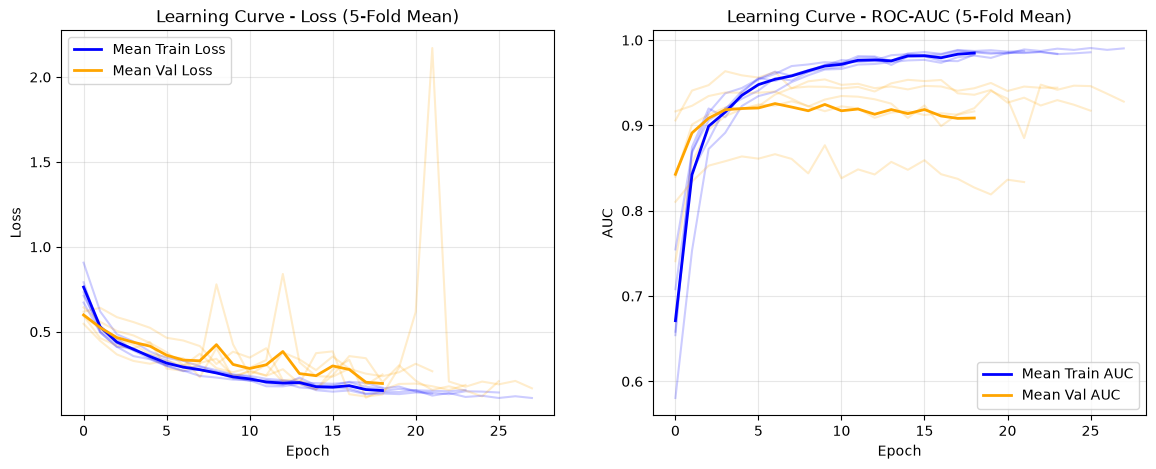


TỐI ƯU HÓA NGƯỠNG PHÂN LOẠI TRÊN DỮ LIỆU OUT-OF-FOLD (VALIDATION)
🎯 OOF Validation ROC-AUC Score: 0.9168
🎯 OOF Validation PR-AUC Score:  0.4087

📊 BẢNG QUÉT NGƯỠNG TRÊN TẬP VALIDATION (OOF) - ƯU TIÊN F2-SCORE:
Threshold Precision Recall F1-Score F2-Score (Rec*2)
     0.10    0.0603 0.9274   0.1132           0.2392
     0.15    0.0814 0.9162   0.1496           0.3004
     0.20    0.0996 0.8883   0.1791           0.3437
     0.25    0.1166 0.8492   0.2050           0.3762
     0.30    0.1332 0.8436   0.2300           0.4081
     0.35    0.1504 0.8156   0.2539           0.4327
     0.40    0.1665 0.8101   0.2762           0.4568
     0.45    0.1819 0.7989   0.2964           0.4760
     0.50    0.1969 0.7877   0.3151           0.4923
     0.55    0.2191 0.7821   0.3423           0.5166
     0.60    0.2370 0.7654   0.3620           0.5294
     0.65    0.2533 0.7430   0.3778           0.5359
     0.70    0.2751 0.7207   0.3981           0.5443
     0.75    0.2958 0.6760   0.4116           0

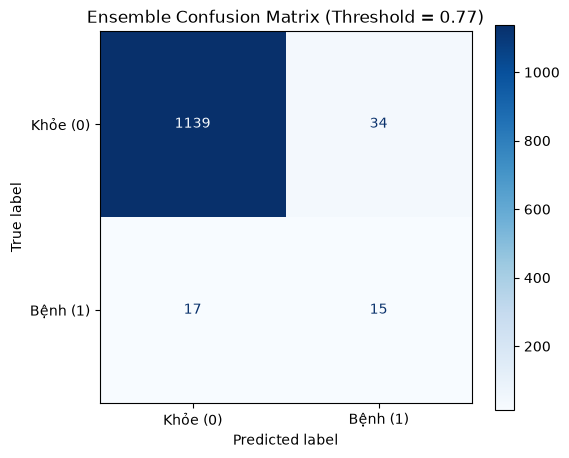

In [8]:
# === 7) Huấn Luyện với Stratified 5-Fold Cross Validation & Đánh Giá Ensemble ===

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report, precision_recall_fscore_support, fbeta_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os

# Cấu hình K-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Các mảng lưu thông tin phục vụ ensemble
oof_preds = np.zeros(len(idx_dev))
models = []
imputers = []
scalers = []

histories = []

print("=" * 60)
print(f"BẮT ĐẦU HUẤN LUYỆN STRATIFIED {n_splits}-FOLD CROSS VALIDATION")
print("=" * 60)

for fold, (train_idx_in, val_idx_in) in enumerate(skf.split(idx_dev, y_dev)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    
    # 1) Lấy dữ liệu thô của fold tương ứng
    X_tr_num_raw = X_num_all_raw[idx_dev[train_idx_in]]
    X_val_num_raw = X_num_all_raw[idx_dev[val_idx_in]]
    
    y_tr_fold = y_dev[train_idx_in]
    y_val_fold = y_dev[val_idx_in]
    
    # 2) Chuẩn hóa dữ liệu trong fold (chống rò rỉ thông tin)
    fold_imputer = SimpleImputer(strategy="mean")
    fold_scaler = StandardScaler()
    
    X_tr_num_scaled = fold_scaler.fit_transform(fold_imputer.fit_transform(X_tr_num_raw))
    X_val_num_scaled = fold_scaler.transform(fold_imputer.transform(X_val_num_raw))
    
    X_tr_seq = X_dev_seq[train_idx_in]
    X_val_seq = X_dev_seq[val_idx_in]
    
    X_tr_job = X_dev_job[train_idx_in]
    X_val_job = X_dev_job[val_idx_in]
    
    # 3) Tính class weights cho fold
    classes_fold = np.array([0, 1])
    weights_fold = compute_class_weight(class_weight="balanced", classes=classes_fold, y=y_tr_fold)
    class_weights_fold = {int(c): float(w) for c, w in zip(classes_fold, weights_fold)}
    
    # 4) Khởi tạo mô hình mới
    fold_model = build_model(n_seq_features, n_num_features, n_job_slots)
    
    # 5) Callbacks cho fold
    early_stop = EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=12,
        restore_best_weights=True,
        verbose=1,
    )
    lr_reduction = ReduceLROnPlateau(
        monitor="val_pr_auc",
        mode="max",
        patience=6,
        factor=0.5,
        min_lr=1e-5,
        verbose=1,
    )
    
    # 6) Huấn luyện
    history = fold_model.fit(
        [X_tr_job, X_tr_seq, X_tr_num_scaled],
        y_tr_fold,
        validation_data=([X_val_job, X_val_seq, X_val_num_scaled], y_val_fold),
        epochs=60,
        batch_size=64,
        class_weight=class_weights_fold,
        callbacks=[early_stop, lr_reduction],
        verbose=0,
    )
    histories.append(history)
    
    # 7) Dự đoán Validation và lưu trữ
    val_preds = fold_model.predict([X_val_job, X_val_seq, X_val_num_scaled], batch_size=64, verbose=0).ravel()
    oof_preds[val_idx_in] = val_preds
    
    # Lưu mô hình & bộ chuẩn hóa của fold
    models.append(fold_model)
    imputers.append(fold_imputer)
    scalers.append(fold_scaler)
    
    fold_auc = roc_auc_score(y_val_fold, val_preds)
    fold_pr_auc = average_precision_score(y_val_fold, val_preds)
    print(f"Fold {fold + 1} Hoàn thành | Val ROC-AUC: {fold_auc:.4f} | Val PR-AUC: {fold_pr_auc:.4f}")

# --- Vẽ biểu đồ Learning Curves trung bình qua các fold ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
os.makedirs("output", exist_ok=True)

for h in histories:
    axes[0].plot(h.history['loss'], color='blue', alpha=0.2)
    axes[0].plot(h.history['val_loss'], color='orange', alpha=0.2)
    axes[1].plot(h.history['auc'], color='blue', alpha=0.2)
    axes[1].plot(h.history['val_auc'], color='orange', alpha=0.2)

min_epochs = min(len(h.history['loss']) for h in histories)
mean_train_loss = np.mean([h.history['loss'][:min_epochs] for h in histories], axis=0)
mean_val_loss = np.mean([h.history['val_loss'][:min_epochs] for h in histories], axis=0)
mean_train_auc = np.mean([h.history['auc'][:min_epochs] for h in histories], axis=0)
mean_val_auc = np.mean([h.history['val_auc'][:min_epochs] for h in histories], axis=0)

axes[0].plot(mean_train_loss, label="Mean Train Loss", color='blue', linewidth=2)
axes[0].plot(mean_val_loss, label='Mean Val Loss', color='orange', linewidth=2)
axes[0].set_title("Learning Curve - Loss (5-Fold Mean)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(mean_train_auc, label="Mean Train AUC", color='blue', linewidth=2)
axes[1].plot(mean_val_auc, label="Mean Val AUC", color='orange', linewidth=2)
axes[1].set_title("Learning Curve - ROC-AUC (5-Fold Mean)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.savefig("output/learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# --- 3) Quét các Ngưỡng Quyết Định trên toàn bộ Out-Of-Fold để chọn Ngưỡng Tối Ưu (Tối đa hóa F2-Score) ---
print("\n" + "=" * 60)
print("TỐI ƯU HÓA NGƯỠNG PHÂN LOẠI TRÊN DỮ LIỆU OUT-OF-FOLD (VALIDATION)")
print("=" * 60)

oof_auc = roc_auc_score(y_dev, oof_preds)
oof_pr_auc = average_precision_score(y_dev, oof_preds)
print(f"🎯 OOF Validation ROC-AUC Score: {oof_auc:.4f}")
print(f"🎯 OOF Validation PR-AUC Score:  {oof_pr_auc:.4f}\n")

thresholds = np.linspace(0.1, 0.9, 81)
best_thresh = 0.5
best_f2 = -1.0
val_sweep_rows = []

for thresh in np.arange(0.1, 0.95, 0.05):
    y_oof_pred_t = (oof_preds >= thresh).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_dev, y_oof_pred_t, average="binary", pos_label=1, zero_division=0)
    f2 = fbeta_score(y_dev, y_oof_pred_t, beta=2, zero_division=0)
    val_sweep_rows.append({
        "Threshold": thresh,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "F2-Score (Rec*2)": f2
    })

for thresh in thresholds:
    y_oof_pred_t = (oof_preds >= thresh).astype(int)
    f2 = fbeta_score(y_dev, y_oof_pred_t, beta=2, zero_division=0)
    if f2 > best_f2:
        best_f2 = f2
        best_thresh = thresh

df_val_sweep = pd.DataFrame(val_sweep_rows)
print("📊 BẢNG QUÉT NGƯỠNG TRÊN TẬP VALIDATION (OOF) - ƯU TIÊN F2-SCORE:")
print(df_val_sweep.to_string(index=False, formatters={
    "Threshold": "{:.2f}".format,
    "Precision": "{:.4f}".format,
    "Recall": "{:.4f}".format,
    "F1-Score": "{:.4f}".format,
    "F2-Score (Rec*2)": "{:.4f}".format
}))

print(f"\n🔑 Ngưỡng tối ưu chọn từ tập Validation (tối đa hóa F2-Score): {best_thresh:.2f} (F2 = {best_f2:.4f})")

# --- 4) Đánh giá Ensemble trên tập TEST với Ngưỡng Tối Ưu đã chọn ---
print("\n" + "=" * 60)
print(f"ĐÁNH GIÁ ENSEMBLE TRÊN TẬP TEST HOLD-OUT VỚI THRESHOLD = {best_thresh:.2f}")
print("=" * 60)

test_probs = []
for fold in range(n_splits):
    X_test_num_fold = scalers[fold].transform(imputers[fold].transform(X_num_all_raw[idx_test]))
    p = models[fold].predict([X_test_job, X_test_seq, X_test_num_fold], batch_size=64, verbose=0).ravel()
    test_probs.append(p)

y_test_prob = np.mean(test_probs, axis=0)

test_auc = roc_auc_score(y_test, y_test_prob)
test_pr_auc = average_precision_score(y_test, y_test_prob)
print(f"🎯 Ensemble Test ROC-AUC Score: {test_auc:.4f}")
print(f"🎯 Ensemble Test PR-AUC Score:  {test_pr_auc:.4f}\n")

y_test_pred = (y_test_prob >= best_thresh).astype(int)

from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (Rows: True, Cols: Pred):")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Khỏe (0)", "Bệnh (1)"], digits=4))

# Vẽ Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Khỏe (0)", "Bệnh (1)"])
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
ax.set_title(f"Ensemble Confusion Matrix (Threshold = {best_thresh:.2f})")
plt.savefig("output/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# === 8) Trích Xuất Vector Đặc Trưng Lâm Sàng (32-dim) Phục Vụ Fusion (GNN) ===

import os
import numpy as np
import pandas as pd

print("🔄 Đang trích xuất đặc trưng Ensemble từ lớp 'fusion_dense'...")

all_ts_vectors = []

for fold in range(n_splits):
    feat_extractor = Model(
        inputs=models[fold].inputs,
        outputs=models[fold].get_layer("fusion_dense").output,
        name=f"timeseries_feature_extractor_fold_{fold+1}"
    )
    
    X_num_all_fold = scalers[fold].transform(imputers[fold].transform(X_num_all_raw))
    
    vecs = feat_extractor.predict(
        [X_job_all, X_seq_all, X_num_all_fold],
        batch_size=64,
        verbose=0
    )
    all_ts_vectors.append(vecs)

ts_vectors = np.mean(all_ts_vectors, axis=0)

print(f"✅ Trích xuất thành công: shape = {ts_vectors.shape}")

# Lưu vector kèm khóa nối `id` sang nhánh ảnh.
# KHÔNG dùng file_name: cột đó chứa họ tên bệnh nhân (PII). Nhánh ảnh cũng đã
# chuyển sang khóa img_id + file_hash vì lý do tương tự.
df_vectors = pd.DataFrame(ts_vectors, columns=[f"ts_feat_{i}" for i in range(ts_vectors.shape[1])])
df_vectors.insert(0, "id", df_raw["id"].to_numpy())
if has_image is not None:
    df_vectors.insert(1, "has_image", has_image)

# Lưu kết quả ra file chuẩn trong thư mục output/
os.makedirs("output", exist_ok=True)
parquet_path = "output/timeseries_features.parquet"
npy_path = "output/timeseries_features.npy"

df_vectors.to_parquet(parquet_path, index=False)
np.save(npy_path, ts_vectors)

print(f"\n🎉 ĐÃ XUẤT THÀNH CÔNG VECTOR CHO NHÁNH FUSION:")
print(f"- File Parquet (khóa `id` + has_image): {parquet_path}")
print(f"- File Npy (chỉ matrix float32):  {npy_path}")


🔄 Đang trích xuất đặc trưng Ensemble từ lớp 'fusion_dense'...
✅ Trích xuất thành công: shape = (8030, 32)

🎉 ĐÃ XUẤT THÀNH CÔNG VECTOR CHO NHÁNH FUSION:
- File Parquet (kèm file_name): output/timeseries_features.parquet
- File Npy (chỉ matrix float32):  output/timeseries_features.npy
